## Seaborn 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline

# Auto reloads notebook when changes are made
%reload_ext autoreload
%autoreload 2

In [2]:
cs_df = pd.read_csv(r"C:\Users\Nada\Downloads\ComputerSales.csv")

In [4]:
# Seaborn provides built in datasets
print(sns.get_dataset_names())

# Load a built in dataset based on US State car crash percentages
crash_df = sns.load_dataset('car_crashes')

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [5]:
crash_df.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


## Distribution Plots

### Distribution Plot

<Axes: xlabel='not_distracted', ylabel='Count'>

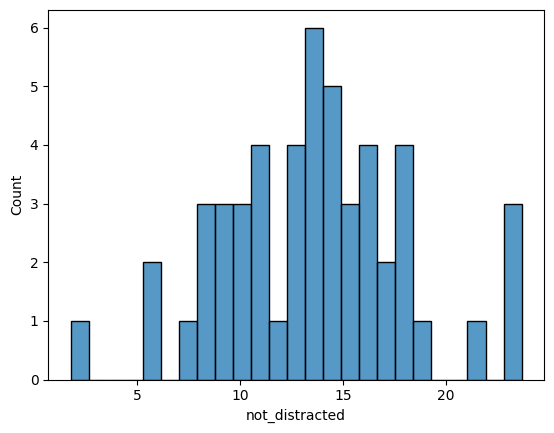

In [6]:
sns.histplot(crash_df['not_distracted'], kde=False, bins=25)

### Joint Plot

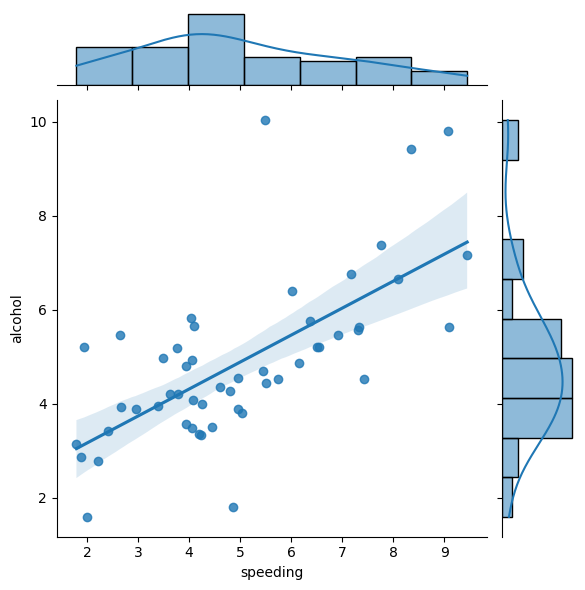

In [7]:
sns.jointplot(x='speeding', y='alcohol', data=crash_df, kind='reg')

### KDE Plot

<Axes: xlabel='alcohol', ylabel='Density'>

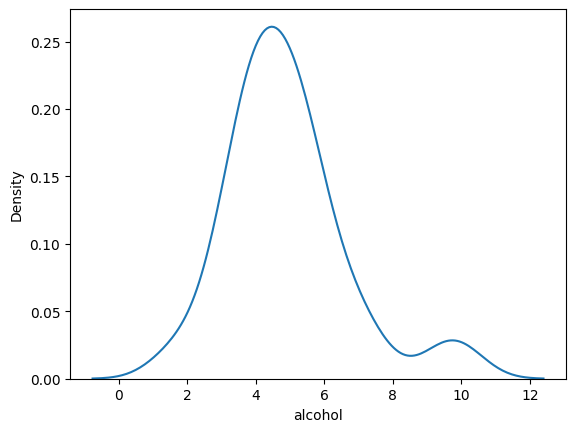

In [11]:
sns.kdeplot(crash_df['alcohol'])

### Pair Plots

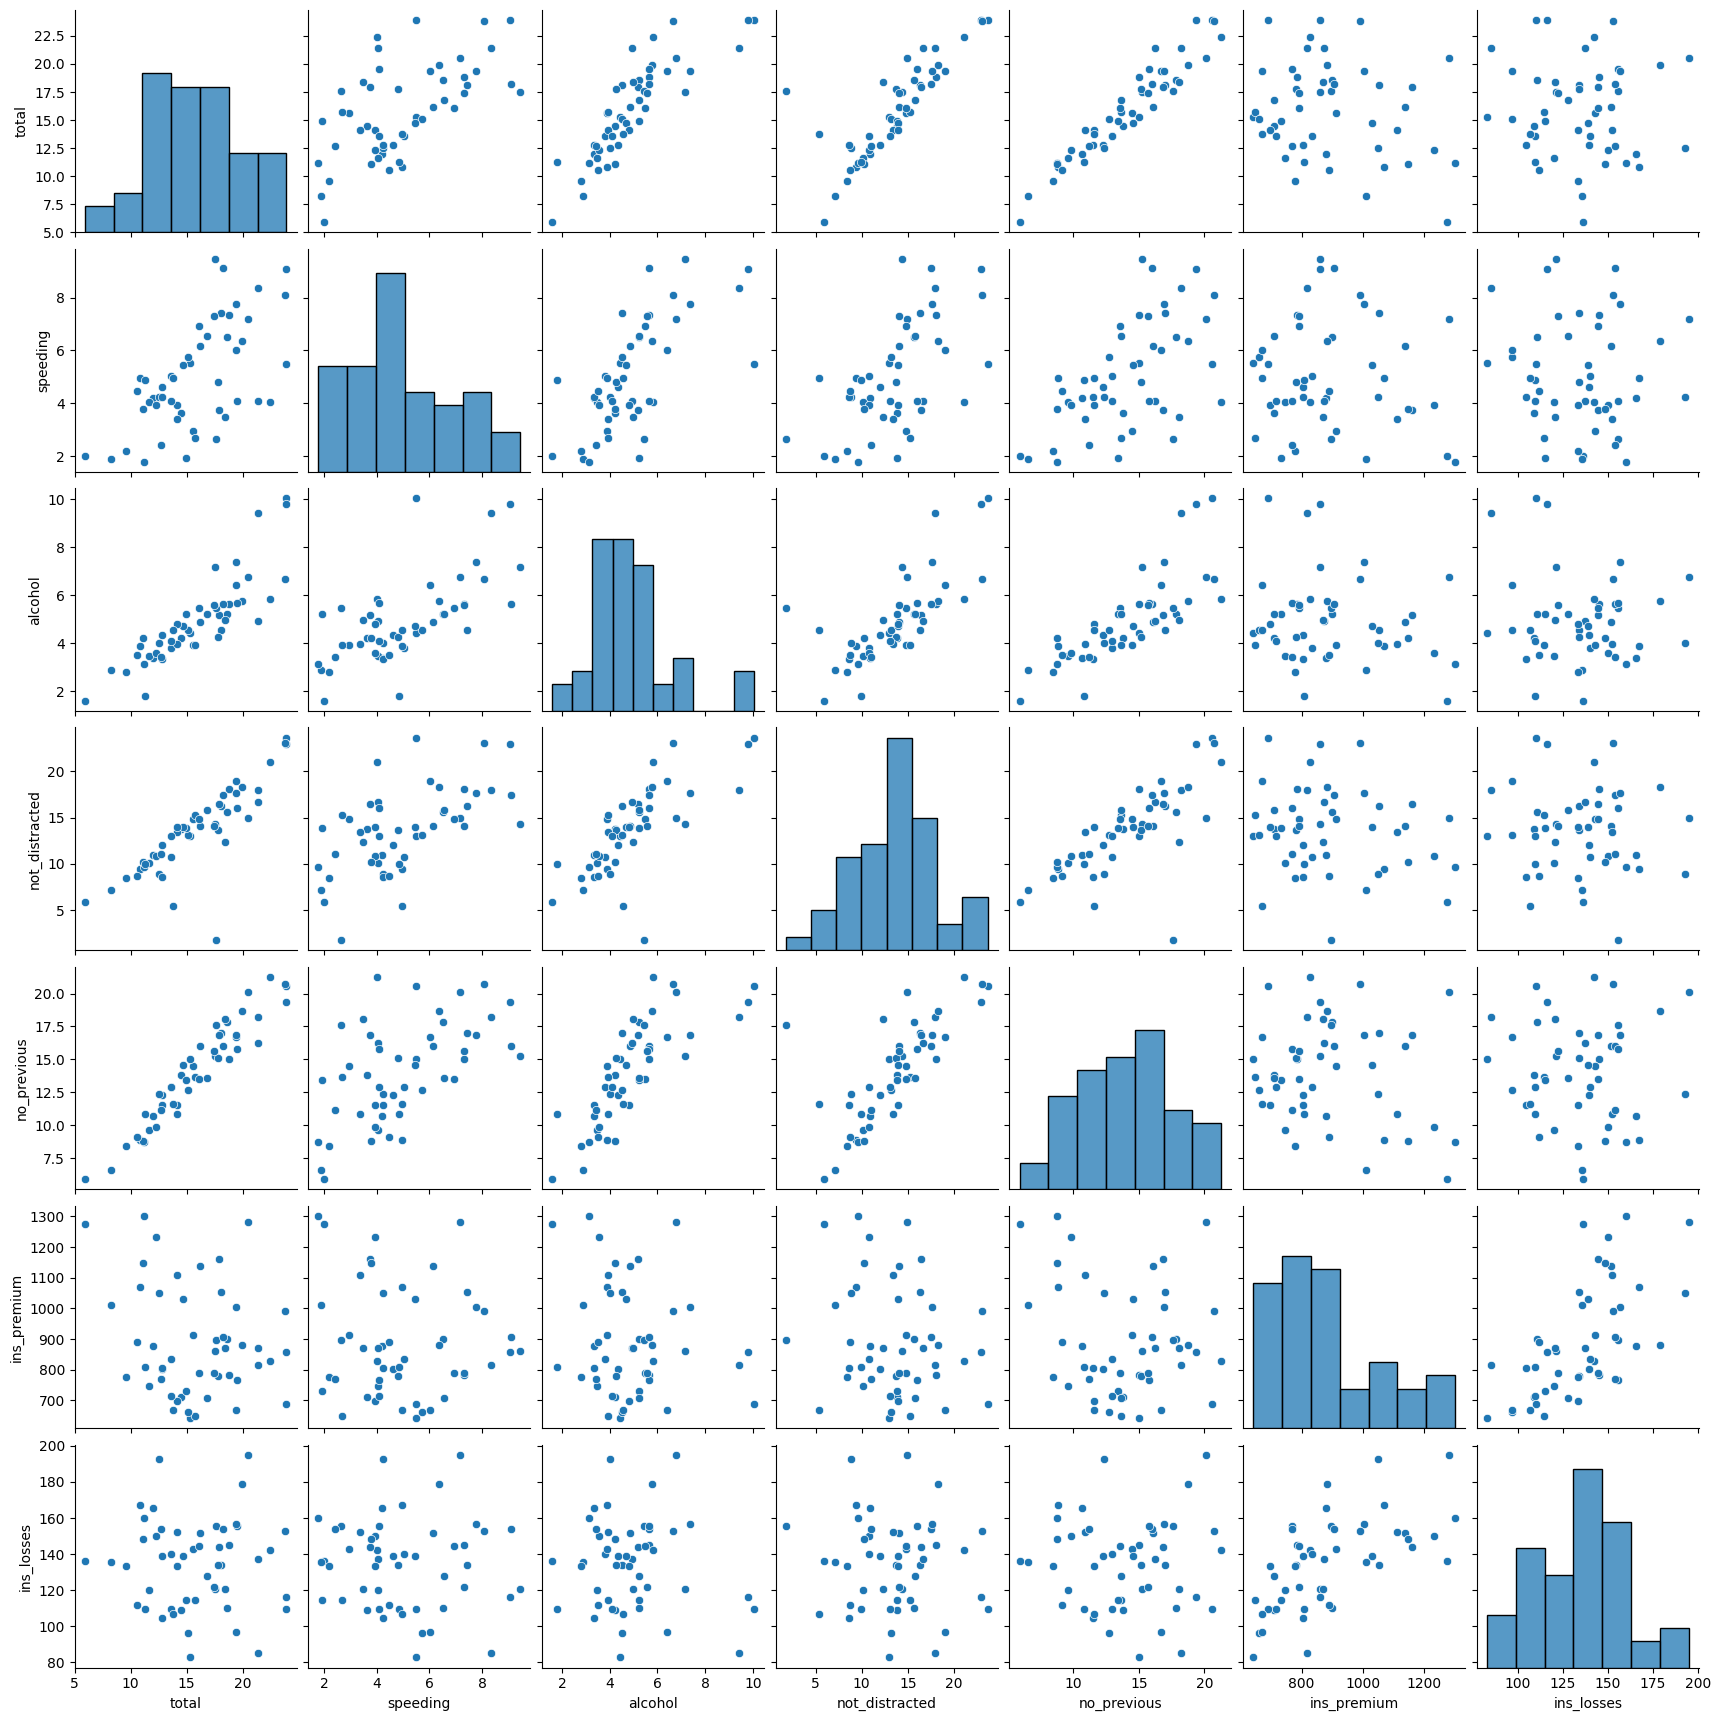

In [8]:
sns.pairplot(crash_df)
tips_df = sns.load_dataset('tips')

### Rug Plots

<Axes: xlabel='tip'>

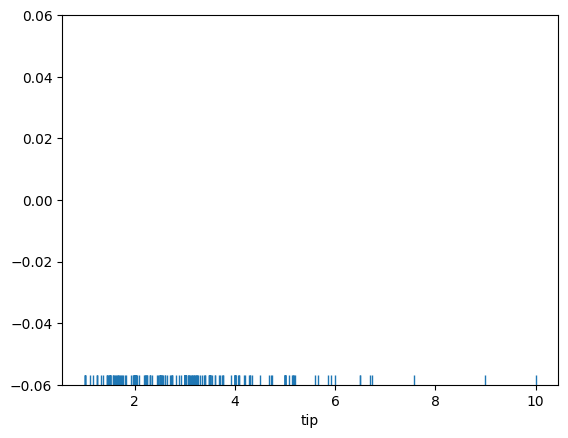

In [9]:
sns.rugplot(tips_df['tip'])

In [15]:
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Styling

<Figure size 800x400 with 0 Axes>

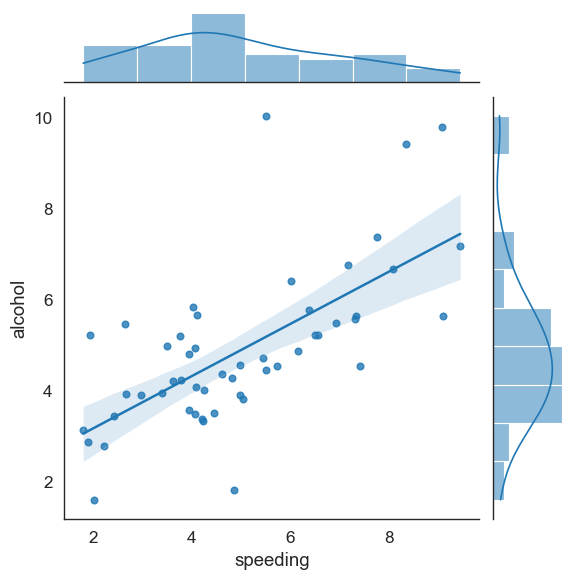

In [14]:
sns.set_style('white')
plt.figure(figsize=(8,4))
sns.set_context('paper', font_scale=1.4)
sns.jointplot(x='speeding', y='alcohol', data=crash_df, kind='reg')

## Categorical Plots

### Bar Plots

<Axes: xlabel='sex', ylabel='total_bill'>

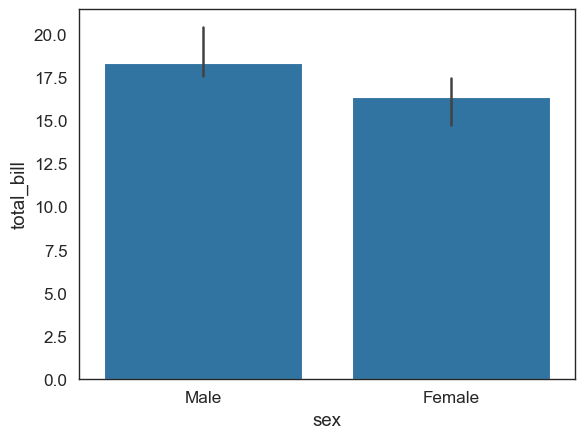

In [16]:
sns.barplot(x='sex',y='total_bill',data=tips_df, estimator=np.median)

### Count Plot

<Axes: xlabel='sex', ylabel='count'>

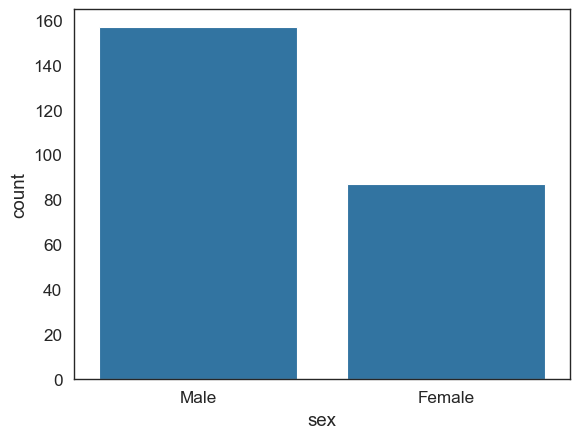

In [17]:
sns.countplot(x='sex',data=tips_df)

### Box Plot

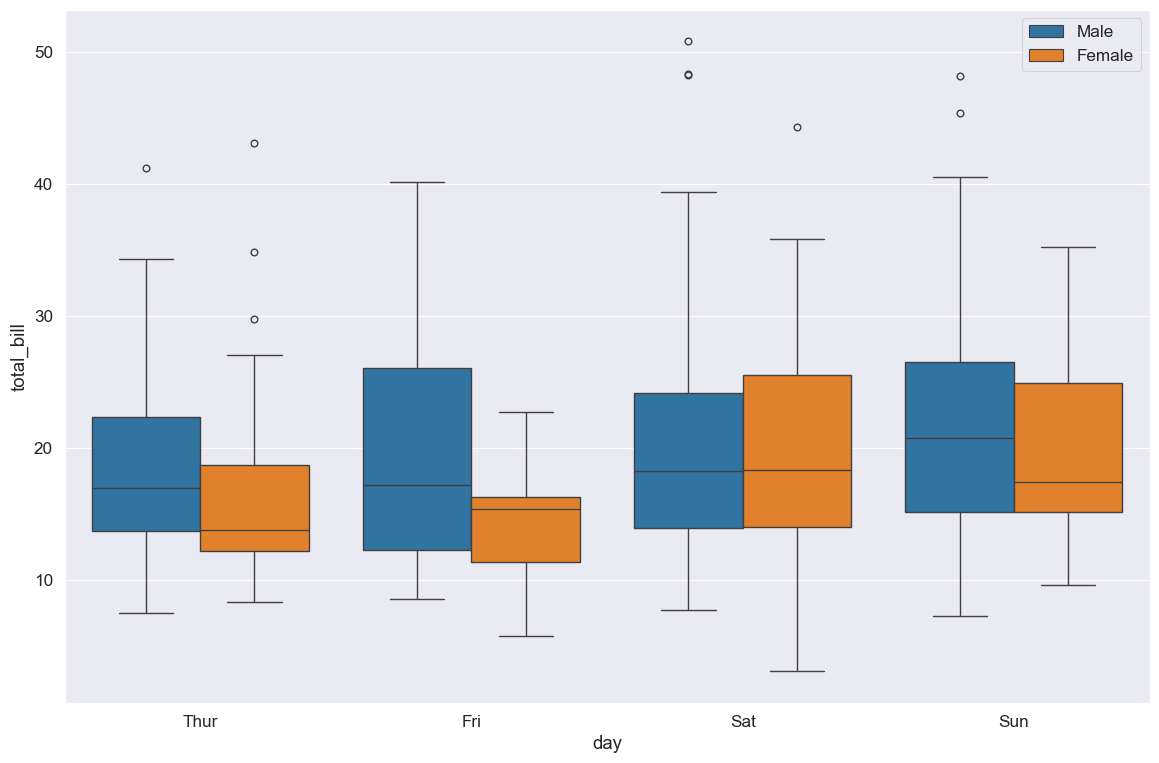

In [18]:
plt.figure(figsize=(14,9))
sns.set_style('darkgrid')
sns.boxplot(x='day',y='total_bill',data=tips_df, hue='sex')
plt.legend(loc=0)

### Violin Plot

<Axes: xlabel='day', ylabel='total_bill'>

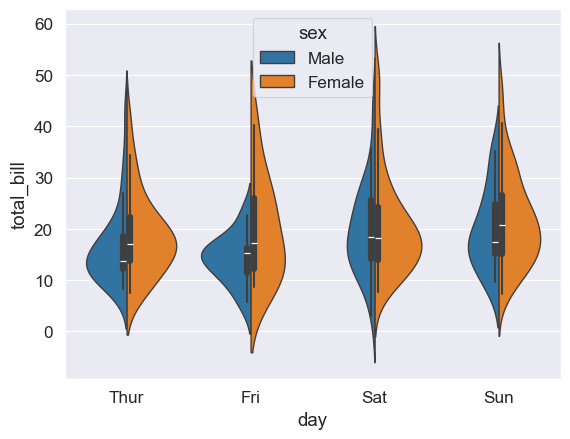

In [19]:
sns.violinplot(x='day',y='total_bill',data=tips_df, hue='sex',split=True)

### Strip Plot

<Axes: xlabel='day', ylabel='total_bill'>

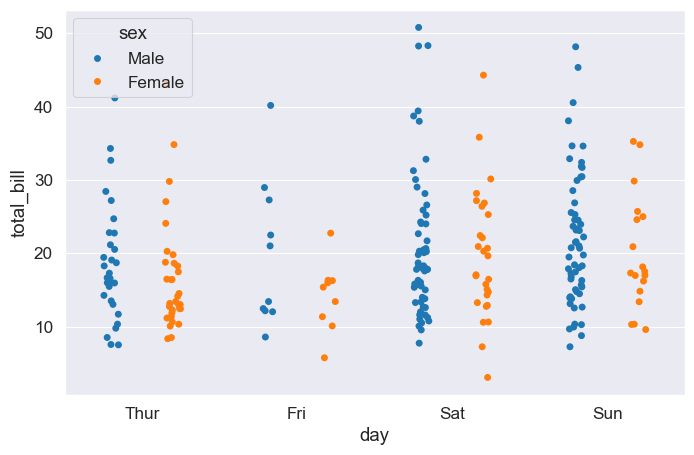

In [20]:
plt.figure(figsize=(8,5))
sns.stripplot(x='day',y='total_bill',data=tips_df, jitter=True, 
              hue='sex', dodge=True)

### Swarm Plot

<Axes: xlabel='day', ylabel='total_bill'>

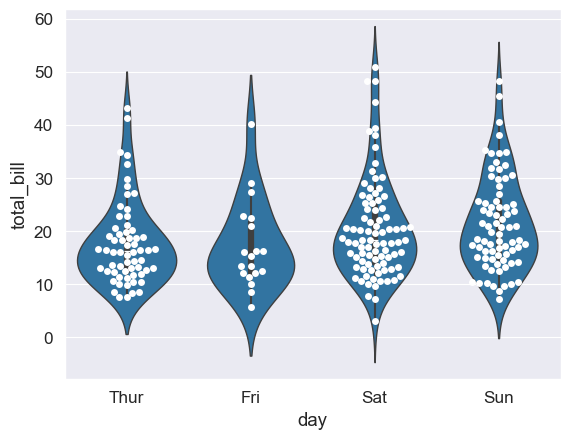

In [21]:
sns.violinplot(x='day',y='total_bill',data=tips_df)
sns.swarmplot(x='day',y='total_bill',data=tips_df, color='white')

### Palettes

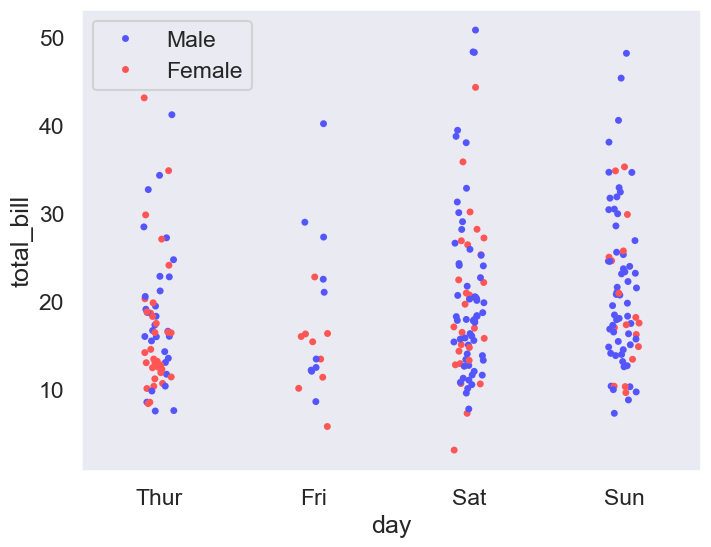

In [23]:
plt.figure(figsize=(8,6))
sns.set_style('dark')
sns.set_context('talk')
sns.stripplot(x='day',y='total_bill',data=tips_df, hue='sex', 
             palette='seismic')
plt.legend(loc=0)

## Matrix Plots

### Heatmaps

<Axes: >

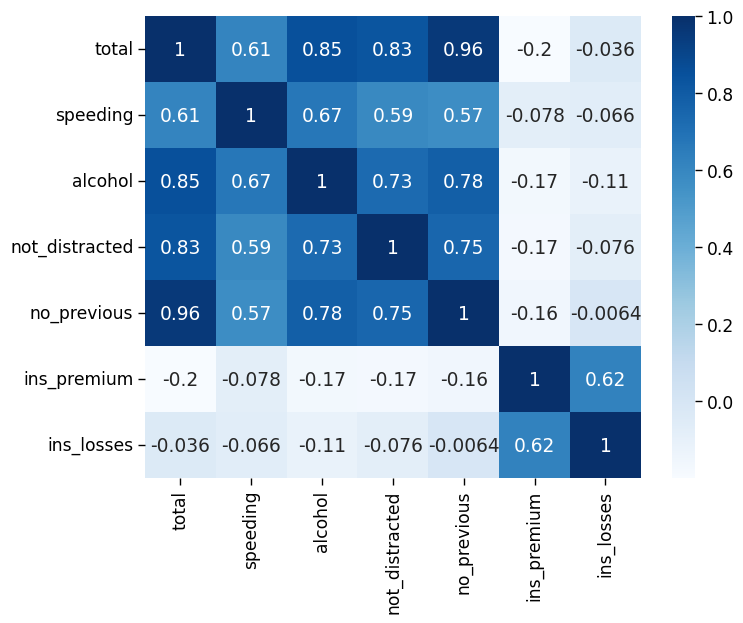

In [10]:
plt.figure(figsize=(8,6))
sns.set_context('paper', font_scale=1.4)
crash_mx = crash_df.corr(numeric_only=True)
sns.heatmap(crash_mx, annot=True, cmap='Blues')

<Axes: xlabel='year', ylabel='month'>

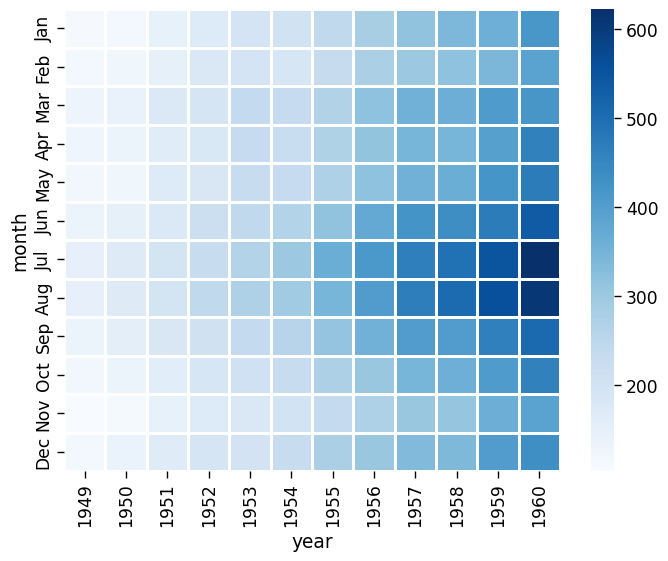

In [11]:
plt.figure(figsize=(8,6))
sns.set_context('paper', font_scale=1.4)
flights = sns.load_dataset("flights")
flights = flights.pivot_table(index='month', columns='year', values='passengers')
sns.heatmap(flights, cmap='Blues', linecolor='white', linewidth=1)

### Cluster Map

In [12]:
iris = sns.load_dataset('iris')

In [13]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Figure size 800x600 with 0 Axes>

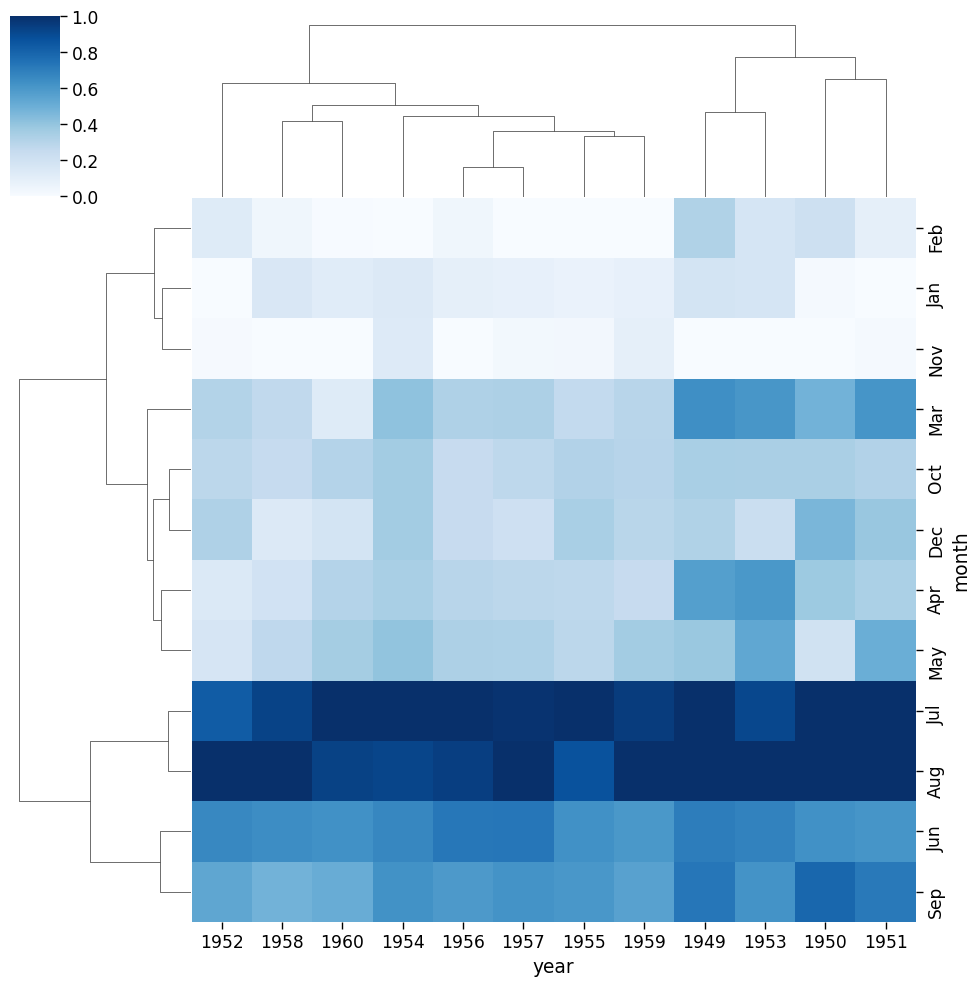

In [14]:
plt.figure(figsize=(8,6))
sns.set_context('paper', font_scale=1.4)
iris = sns.load_dataset("iris")
#species = iris.pop("species")
#sns.clustermap(iris)
flights = sns.load_dataset("flights")
flights = flights.pivot_table(index='month', columns='year', values='passengers')
sns.clustermap(flights,cmap="Blues", standard_scale=1)


### PairGrid

<Figure size 800x600 with 0 Axes>

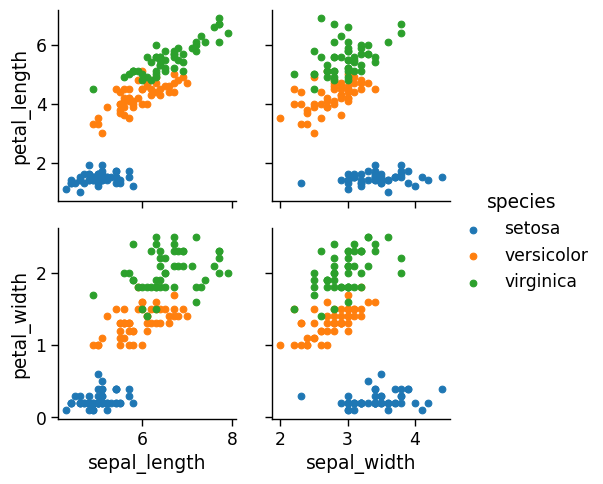

In [15]:
plt.figure(figsize=(8,6))
sns.set_context('paper', font_scale=1.4)
iris_g = sns.PairGrid(iris, hue="species",
                      x_vars=["sepal_length", "sepal_width"],
                      y_vars=["petal_length", "petal_width"])

iris_g.map(plt.scatter)
iris_g.add_legend()


### Facet Grid

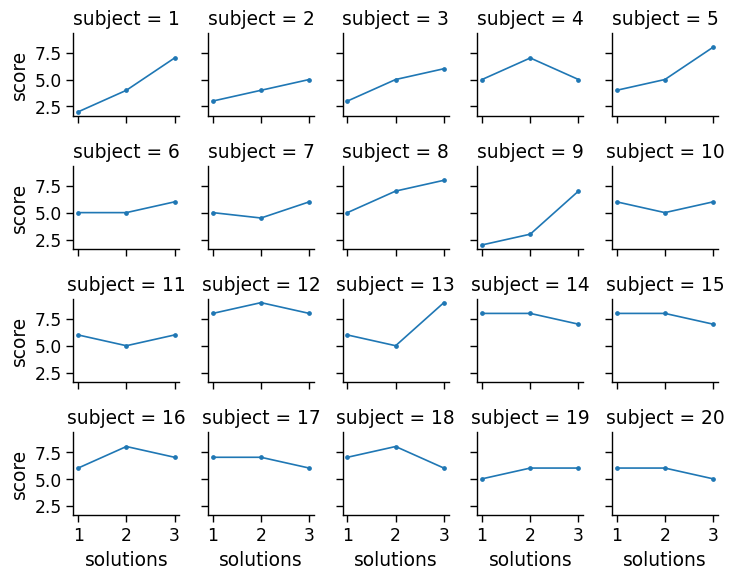

In [17]:
att_df = sns.load_dataset("attention")
att_fg = sns.FacetGrid(att_df, col='subject', col_wrap=5, height=1.5)
att_fg.map(plt.plot, 'solutions', 'score', marker='.')

### Regression Plots

In [18]:
tips_df = sns.load_dataset('tips')
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

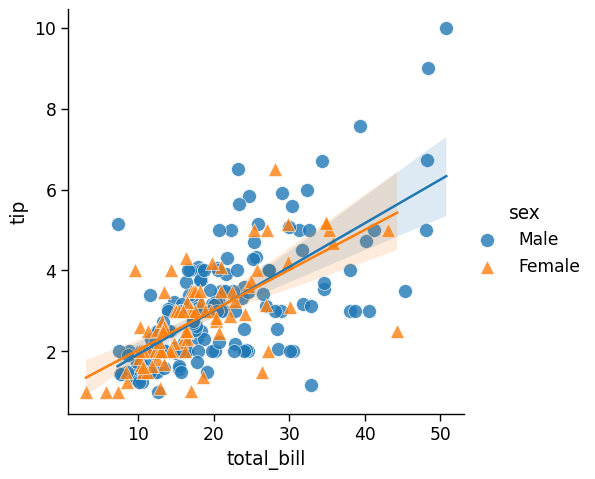

In [20]:
plt.figure(figsize=(8,6))
sns.set_context('paper', font_scale=1.4)

plt.figure(figsize=(8,6))
sns.lmplot(x='total_bill', y='tip', hue='sex', data=tips_df, markers=['o', '^'], 
          scatter_kws={'s': 100, 'linewidths': 0.5, 'edgecolor': 'w'})

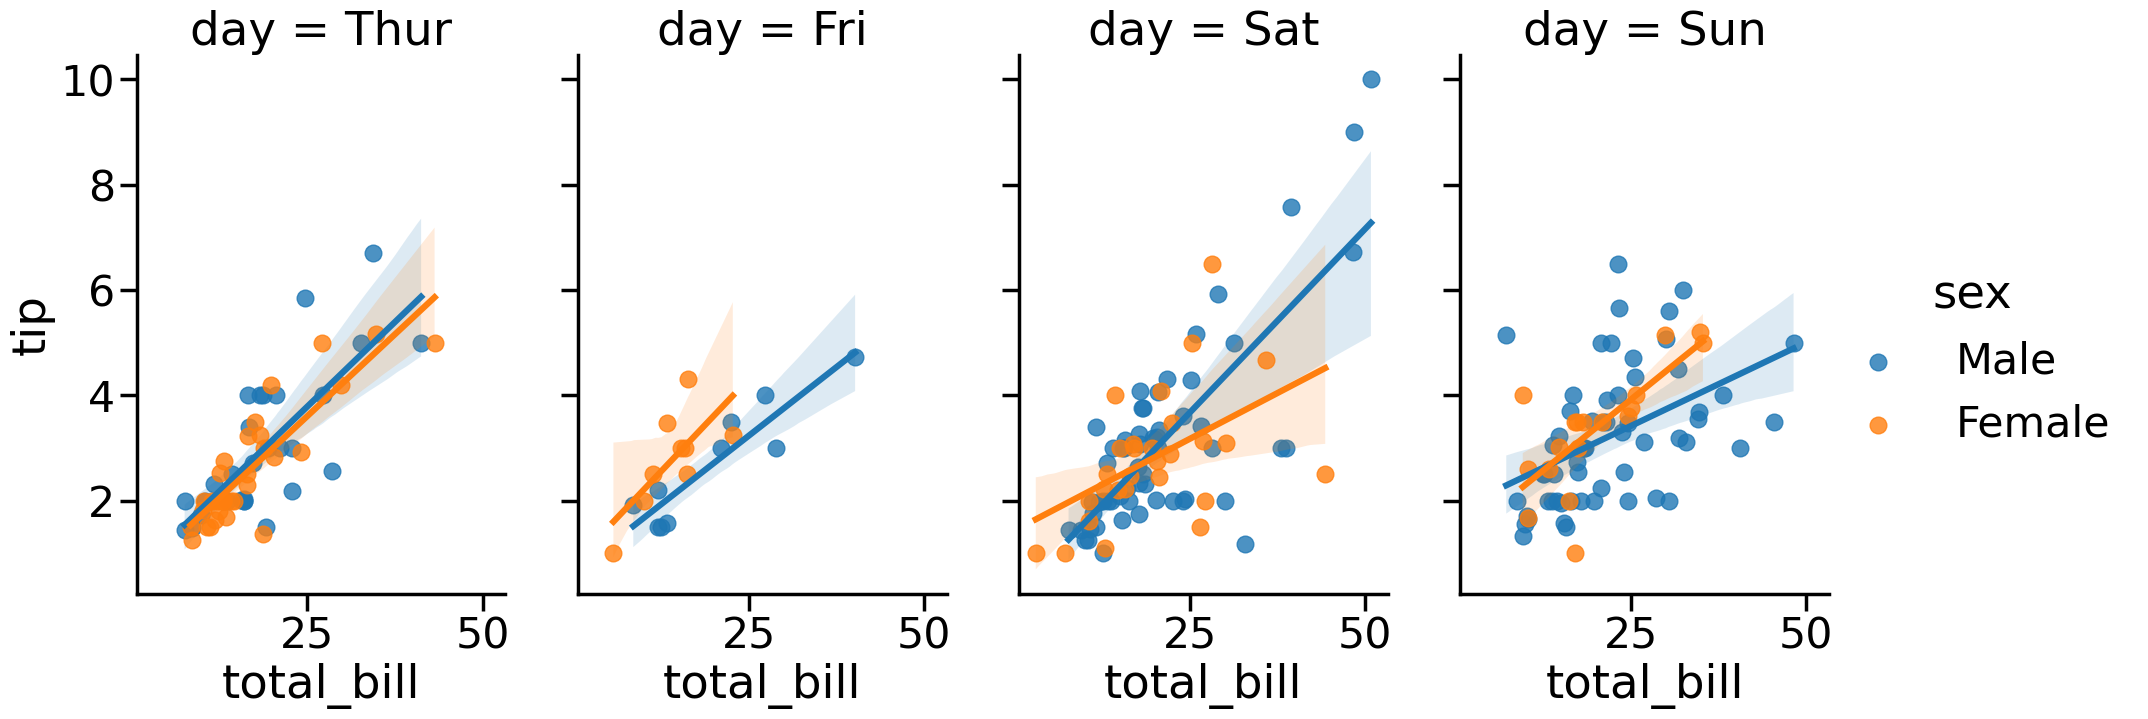

In [21]:
tips_df.head()
sns.set_context('poster', font_scale=1.4)
sns.lmplot(x='total_bill', y='tip', data=tips_df, col='day', hue='sex',
          height=8, aspect=0.6)